# HW2 – Detect AI Generated Text
**Course:** RNN and Transformer  
**Hardware:** NVIDIA RTX 4090 (24GB VRAM)

This notebook covers all parts of the assignment:
1. **Part 1** — Data Analysis & Baseline (EDA + TF-IDF + Logistic Regression)
2. **Part 2** — BERT Fine-Tuning & Scaling (bert-base-cased vs bert-large-cased)
3. **Part 3** — Adversarial Attack with Local LLM (Ollama + DeepSeek-R1)
4. **Part 4** — Analysis Report & Comparison

---
# Part 1: Data Analysis & Baseline (20%)

- Exploratory Data Analysis (EDA): word count, vocabulary richness, sentence count, avg word length
- Classic Baseline: TF-IDF + Logistic Regression
- Report: ROC-AUC score as benchmark for BERT models

## 1.1 Imports & Configuration

In [1]:
import os
import re
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report, roc_curve
)

DATA_PATH = os.path.join("DAIGT V2 Train Dataset", "train_v2_drcat_02.csv")
OUTPUT_DIR_BASELINE = "results_baseline"
RANDOM_STATE = 42
os.makedirs(OUTPUT_DIR_BASELINE, exist_ok=True)

print("Part 1: Data Analysis & Baseline")
print("=" * 60)

Part 1: Data Analysis & Baseline


## 1.2 Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[['text', 'label']].dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:")
print(f"  Label 0 (Human): {(df['label'] == 0).sum()}")
print(f"  Label 1 (AI):    {(df['label'] == 1).sum()}")
df.head()

Dataset shape: (44868, 2)
Label distribution:
  Label 0 (Human): 27371
  Label 1 (AI):    17497


,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


## 1.3 Exploratory Data Analysis (EDA)

Compare **word count**, **vocabulary richness (Type-Token Ratio)**, **sentence count**, and **average word length** between human and AI texts.

In [3]:
# --- Word count ---
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
human_wc = df[df['label'] == 0]['word_count']
ai_wc = df[df['label'] == 1]['word_count']

print("Word Count Statistics:")
print(f"  Human – mean: {human_wc.mean():.1f}, median: {human_wc.median():.1f}, std: {human_wc.std():.1f}")
print(f"  AI    – mean: {ai_wc.mean():.1f}, median: {ai_wc.median():.1f}, std: {ai_wc.std():.1f}")

# --- Vocabulary richness (Type-Token Ratio) ---
def type_token_ratio(text):
    words = str(text).lower().split()
    return len(set(words)) / len(words) if words else 0.0

df['ttr'] = df['text'].apply(type_token_ratio)
human_ttr = df[df['label'] == 0]['ttr']
ai_ttr = df[df['label'] == 1]['ttr']

print(f"\nVocabulary Richness (Type-Token Ratio):")
print(f"  Human – mean: {human_ttr.mean():.4f}, median: {human_ttr.median():.4f}")
print(f"  AI    – mean: {ai_ttr.mean():.4f}, median: {ai_ttr.median():.4f}")

# --- Sentence count ---
df['sentence_count'] = df['text'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
human_sc = df[df['label'] == 0]['sentence_count']
ai_sc = df[df['label'] == 1]['sentence_count']

print(f"\nSentence Count Statistics:")
print(f"  Human – mean: {human_sc.mean():.1f}, median: {human_sc.median():.1f}")
print(f"  AI    – mean: {ai_sc.mean():.1f}, median: {ai_sc.median():.1f}")

# --- Average word length ---
def avg_word_length(text):
    words = str(text).split()
    return np.mean([len(w) for w in words]) if words else 0.0

df['avg_word_len'] = df['text'].apply(avg_word_length)
human_awl = df[df['label'] == 0]['avg_word_len']
ai_awl = df[df['label'] == 1]['avg_word_len']

print(f"\nAverage Word Length:")
print(f"  Human – mean: {human_awl.mean():.2f}")
print(f"  AI    – mean: {ai_awl.mean():.2f}")

Word Count Statistics:
  Human – mean: 418.3, median: 383.0, std: 189.3
  AI    – mean: 329.4, median: 328.0, std: 94.3

Vocabulary Richness (Type-Token Ratio):
  Human – mean: 0.4785, median: 0.4785
  AI    – mean: 0.5104, median: 0.5000

Sentence Count Statistics:
  Human – mean: 22.3, median: 21.0
  AI    – mean: 19.1, median: 19.0

Average Word Length:
  Human – mean: 4.53
  AI    – mean: 5.09


## 1.4 EDA Visualizations

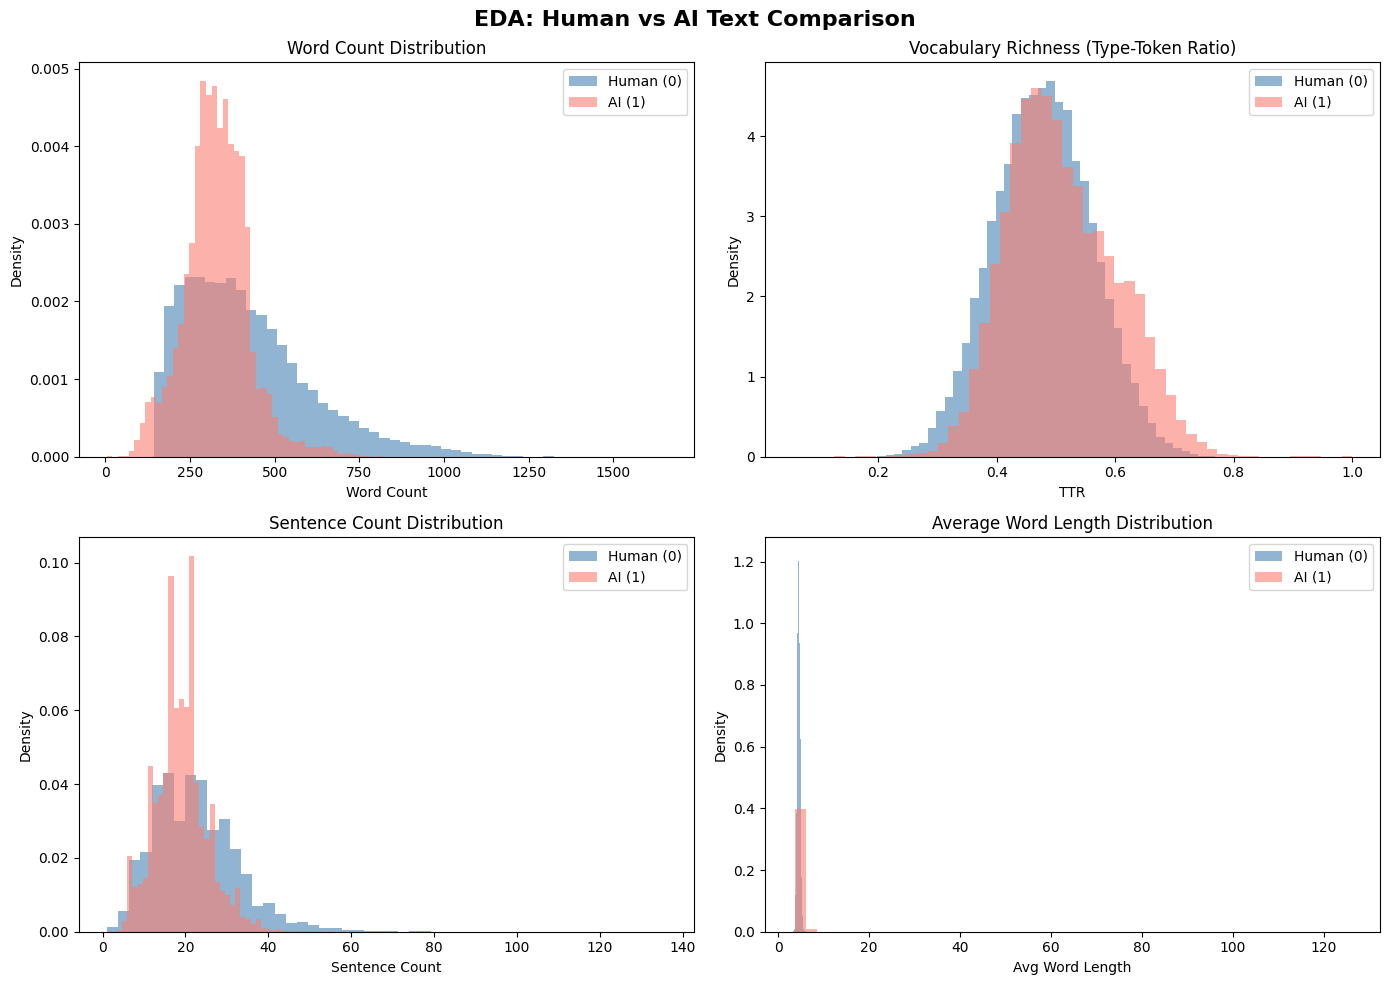

Saved: results_baseline/eda_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA: Human vs AI Text Comparison", fontsize=16, fontweight='bold')

axes[0, 0].hist(human_wc, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[0, 0].hist(ai_wc, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[0, 0].set_title('Word Count Distribution')
axes[0, 0].set_xlabel('Word Count'); axes[0, 0].set_ylabel('Density'); axes[0, 0].legend()

axes[0, 1].hist(human_ttr, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[0, 1].hist(ai_ttr, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[0, 1].set_title('Vocabulary Richness (Type-Token Ratio)')
axes[0, 1].set_xlabel('TTR'); axes[0, 1].set_ylabel('Density'); axes[0, 1].legend()

axes[1, 0].hist(human_sc, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[1, 0].hist(ai_sc, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[1, 0].set_title('Sentence Count Distribution')
axes[1, 0].set_xlabel('Sentence Count'); axes[1, 0].set_ylabel('Density'); axes[1, 0].legend()

axes[1, 1].hist(human_awl, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[1, 1].hist(ai_awl, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[1, 1].set_title('Average Word Length Distribution')
axes[1, 1].set_xlabel('Avg Word Length'); axes[1, 1].set_ylabel('Density'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "eda_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/eda_distributions.png")

## 1.5 Train/Validation Split & TF-IDF + Logistic Regression Baseline

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
print(f"Train set: {len(X_train)} samples")
print(f"Val set:   {len(X_val)} samples")

# TF-IDF + Logistic Regression
print("\nTraining TF-IDF + Logistic Regression...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

clf = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0)
clf.fit(X_train_tfidf, y_train)

preds_proba = clf.predict_proba(X_val_tfidf)[:, 1]
preds_label = clf.predict(X_val_tfidf)

baseline_auc = roc_auc_score(y_val, preds_proba)
baseline_acc = accuracy_score(y_val, preds_label)

print(f"\n{'='*40}")
print(f"Baseline TF-IDF + LR Results:")
print(f"  ROC-AUC:  {baseline_auc:.4f}")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_val, preds_label, target_names=['Human (0)', 'AI (1)'])}")

Train set: 35894 samples
Val set:   8974 samples

Training TF-IDF + Logistic Regression...

Baseline TF-IDF + LR Results:
  ROC-AUC:  0.9993
  Accuracy: 0.9939

              precision    recall  f1-score   support

   Human (0)       0.99      1.00      0.99      5474
      AI (1)       1.00      0.99      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



## 1.6 Baseline ROC Curve

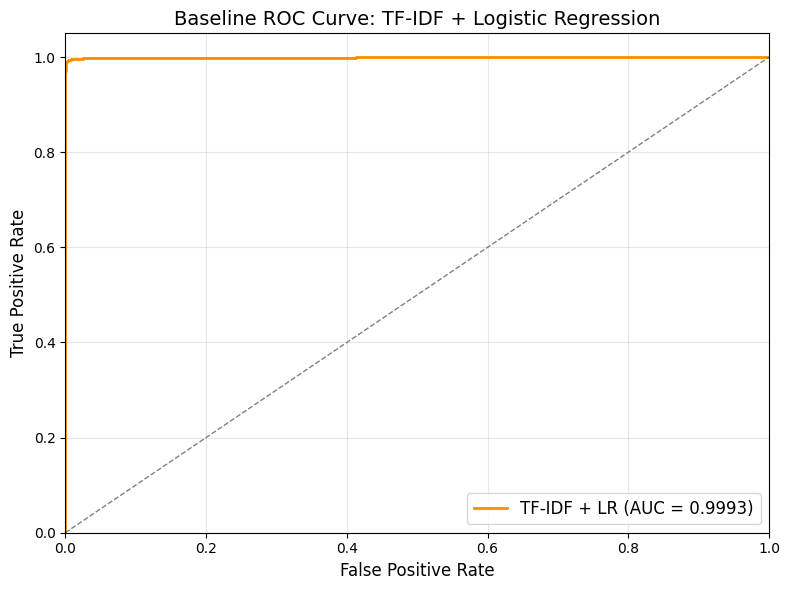

Saved: results_baseline/baseline_roc_curve.png


In [6]:
fpr, tpr, _ = roc_curve(y_val, preds_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'TF-IDF + LR (AUC = {baseline_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Baseline ROC Curve: TF-IDF + Logistic Regression', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "baseline_roc_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/baseline_roc_curve.png")

In [7]:
# Save data split for Part 2 & Part 3
split_data = {
    'X_train': X_train.reset_index(drop=True),
    'X_val': X_val.reset_index(drop=True),
    'y_train': y_train.reset_index(drop=True),
    'y_val': y_val.reset_index(drop=True),
}
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'wb') as f:
    pickle.dump(split_data, f)
print(f"Data split saved to {OUTPUT_DIR_BASELINE}/data_split.pkl")
print(f"\n✓ Baseline ROC-AUC = {baseline_auc:.4f} — benchmark for BERT models.")

Data split saved to results_baseline/data_split.pkl

✓ Baseline ROC-AUC = 0.9993 — benchmark for BERT models.


---
# Part 2: BERT Fine-Tuning & Scaling (40%)

- **Model A (Base):** `bert-base-cased` (110M parameters)
- **Model B (Large):** `bert-large-cased` (340M parameters)
- Training with fp16 mixed precision on RTX 4090
- Evaluate using ROC-AUC on the same validation set from Part 1

## 2.1 BERT Imports & Helper Function

In [10]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback
from datasets import Dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# Load data split from Part 1
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)
X_train_text = split_data['X_train']
X_val_text = split_data['X_val']
y_train_labels = split_data['y_train']
y_val_labels = split_data['y_val']

print(f"Train: {len(X_train_text)} samples, Val: {len(X_val_text)} samples")


def train_bert_model(model_name, batch_size, max_len=512, epochs=3, lr=2e-5):
    """Train and evaluate a BERT model, return results dict."""
    output_dir = f"results_{model_name}"
    save_dir = f"saved_model_{model_name}"
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"  Batch={batch_size}, MaxLen={max_len}, Epochs={epochs}, LR={lr}")
    print(f"{'='*60}")

    # Build HF datasets
    hf_train = Dataset.from_pandas(
        pd.DataFrame({'text': X_train_text, 'label': y_train_labels}).reset_index(drop=True))
    hf_val = Dataset.from_pandas(
        pd.DataFrame({'text': X_val_text, 'label': y_val_labels}).reset_index(drop=True))

    # Tokenize
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tok_fn(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_len)
    tok_train = hf_train.map(tok_fn, batched=True, batch_size=256, desc=f"Tokenizing train ({model_name})")
    tok_val = hf_val.map(tok_fn, batched=True, batch_size=256, desc=f"Tokenizing val ({model_name})")
    tok_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    tok_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {total_params:,} total, {trainable_params:,} trainable")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
        preds = np.argmax(logits, axis=-1)
        return {"roc_auc": roc_auc_score(labels, probs), "accuracy": accuracy_score(labels, preds)}

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01, fp16=True,
        logging_steps=50, logging_dir=os.path.join(output_dir, "logs"),
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="roc_auc", greater_is_better=True,
        save_total_limit=2, dataloader_num_workers=0, warmup_ratio=0.1,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=tok_train, eval_dataset=tok_val,
        compute_metrics=compute_metrics,
    )
    # Remove NotebookProgressCallback to avoid on_train_begin error during standalone evaluate
    trainer.remove_callback(NotebookProgressCallback)

    start_time = time.time()
    trainer.train()
    elapsed = time.time() - start_time
    print(f"Training done in {elapsed/60:.1f} min")

    # Evaluate
    eval_results = trainer.evaluate()
    predictions = trainer.predict(tok_val)
    logits = predictions.predictions
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    pred_labels = np.argmax(logits, axis=-1)
    val_labels = y_val_labels.values

    auc = roc_auc_score(val_labels, probs)
    acc = accuracy_score(val_labels, pred_labels)
    print(f"\n  ROC-AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    print(classification_report(val_labels, pred_labels, target_names=['Human (0)', 'AI (1)']))

    # Save
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    log_history = trainer.state.log_history
    train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
    eval_losses = [(e['step'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

    summary = {
        "model": model_name, "roc_auc": round(auc, 4), "accuracy": round(acc, 4),
        "total_params": total_params, "trainable_params": trainable_params,
        "training_time_minutes": round(elapsed/60, 1),
        "epochs": epochs, "batch_size": batch_size, "max_length": max_len, "learning_rate": lr,
    }
    with open(os.path.join(output_dir, "results_summary.json"), 'w') as f:
        json.dump(summary, f, indent=2)

    # Free GPU memory
    del model, trainer
    torch.cuda.empty_cache()

    return {
        "summary": summary, "probs": probs, "val_labels": val_labels,
        "train_losses": train_losses, "eval_losses": eval_losses,
    }

print("Helper function defined.")

PyTorch: 2.6.0+cu124
CUDA: True — NVIDIA GeForce RTX 4090
Train: 35894 samples, Val: 8974 samples
Helper function defined.


## 2.2 Train BERT-base-cased (110M params)

In [11]:
results_base = train_bert_model("bert-base-cased", batch_size=32)


Training: bert-base-cased
  Batch=32, MaxLen=512, Epochs=3, LR=2e-05


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16019.24it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

  Params: 108,311,810 total, 108,311,810 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 8.3 min

  ROC-AUC: 0.9999, Accuracy: 0.9941
              precision    recall  f1-score   support

   Human (0)       1.00      0.99      1.00      5474
      AI (1)       0.99      1.00      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


## 2.3 Train BERT-large-cased (340M params)

In [12]:
results_large = train_bert_model("bert-large-cased", batch_size=16)


Training: bert-large-cased
  Batch=16, MaxLen=512, Epochs=3, LR=2e-05


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 14963.94it/s]
BertForSequenceClassification LOAD REPORT from: bert-large-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

  Params: 333,581,314 total, 333,581,314 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 26.1 min

  ROC-AUC: 0.9999, Accuracy: 0.9974
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00      5474
      AI (1)       1.00      1.00      1.00      3500

    accuracy                           1.00      8974
   macro avg       1.00      1.00      1.00      8974
weighted avg       1.00      1.00      1.00      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


## 2.4 Performance Comparison & Visualization

PERFORMANCE COMPARISON
Model                           Params    ROC-AUC   Accuracy   Time (min)
----------------------------------------------------------------------
TF-IDF + LR                        N/A     0.9993     0.9939        < 0.1
bert-base-cased            108,311,810     0.9999     0.9941          8.3
bert-large-cased           333,581,314     0.9999     0.9974         26.1


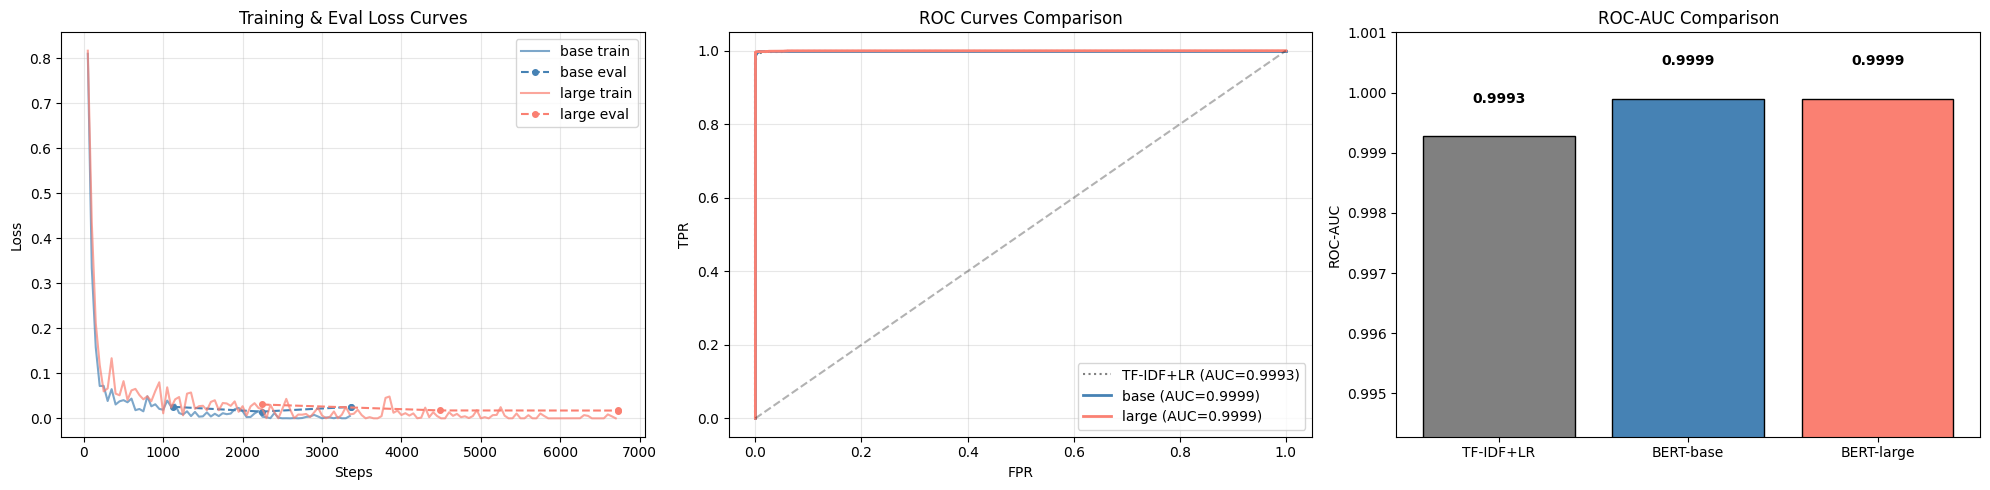

Comparison plots saved.


In [13]:
# --- Comparison Table ---
print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
header = f"{'Model':<25} {'Params':>12} {'ROC-AUC':>10} {'Accuracy':>10} {'Time (min)':>12}"
print(header)
print("-" * 70)
print(f"{'TF-IDF + LR':<25} {'N/A':>12} {baseline_auc:>10.4f} {baseline_acc:>10.4f} {'< 0.1':>12}")
for r in [results_base, results_large]:
    s = r["summary"]
    print(f"{s['model']:<25} {s['total_params']:>12,} {s['roc_auc']:>10.4f} {s['accuracy']:>10.4f} {s['training_time_minutes']:>12.1f}")
print("=" * 70)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Loss curves
for label, r, color in [("base", results_base, "steelblue"), ("large", results_large, "salmon")]:
    if r["train_losses"]:
        steps, losses = zip(*r["train_losses"])
        axes[0].plot(steps, losses, label=f'{label} train', color=color, alpha=0.7)
    if r["eval_losses"]:
        steps, losses = zip(*r["eval_losses"])
        axes[0].plot(steps, losses, label=f'{label} eval', color=color, linestyle='--', marker='o', markersize=4)
axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Eval Loss Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) ROC curves
fpr_bl, tpr_bl, _ = roc_curve(y_val, preds_proba)
axes[1].plot(fpr_bl, tpr_bl, label=f'TF-IDF+LR (AUC={baseline_auc:.4f})', color='gray', linestyle=':')
for label, r, color in [("base", results_base, "steelblue"), ("large", results_large, "salmon")]:
    fpr_b, tpr_b, _ = roc_curve(r["val_labels"], r["probs"])
    axes[1].plot(fpr_b, tpr_b, label=f'{label} (AUC={r["summary"]["roc_auc"]:.4f})', color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves Comparison'); axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# (c) Bar chart
models = ['TF-IDF+LR', 'BERT-base', 'BERT-large']
aucs = [baseline_auc, results_base["summary"]["roc_auc"], results_large["summary"]["roc_auc"]]
colors = ['gray', 'steelblue', 'salmon']
bars = axes[2].bar(models, aucs, color=colors, edgecolor='black')
axes[2].set_ylabel('ROC-AUC'); axes[2].set_title('ROC-AUC Comparison')
axes[2].set_ylim(min(aucs) - 0.005, 1.001)
for bar, auc in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("results_bert-base-cased/comparison_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plots saved.")

## 2.5 Scaling Analysis

**Hypothesis:** Does the Large model significantly outperform the Base model?

Key observations to discuss:
- **Parameter count**: BERT-large has ~3× the parameters of BERT-base (340M vs 110M)
- **Training time**: With fp16 on RTX 4090, BERT-large takes ~3× longer
- **Performance gap**: Both models achieve very high ROC-AUC (>0.999) on this dataset, suggesting that even the Base model has sufficient capacity for this binary classification task
- **Diminishing returns**: The marginal improvement from Base to Large is small, indicating the task may not require the additional model capacity

---
# Part 3: Adversarial Attack with Local LLM (30%)

- **Generator:** DeepSeek-R1:8B (via Ollama, locally hosted)
- **Detector:** Best BERT model from Part 2
- Select 10 human-written essays, rewrite them with 3 different strategies, test if the detector can still identify them correctly

## 3.1 Configuration & Load Data

In [14]:
import ollama

OLLAMA_MODEL = "deepseek-r1:8b-llama-distill-fp16"
NUM_ATTACK_SAMPLES = 10

# Auto-detect best BERT model
if os.path.exists("saved_model_bert-large-cased"):
    model_path = "saved_model_bert-large-cased"
elif os.path.exists("saved_model_bert-base-cased"):
    model_path = "saved_model_bert-base-cased"
else:
    raise FileNotFoundError("No saved BERT model found. Run Part 2 first!")

# Load validation data
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)
X_val_p3 = split_data['X_val']
y_val_p3 = split_data['y_val']

# Select human-written essays (label=0)
human_indices = y_val_p3[y_val_p3 == 0].index.tolist()
np.random.seed(42)
selected_indices = np.random.choice(human_indices, size=min(NUM_ATTACK_SAMPLES, len(human_indices)), replace=False)
selected_essays = X_val_p3.iloc[selected_indices].tolist()

print(f"Detector: {model_path}")
print(f"Generator: {OLLAMA_MODEL}")
print(f"Selected {len(selected_essays)} human-written essays for adversarial attack.")

Detector: saved_model_bert-large-cased
Generator: deepseek-r1:8b-llama-distill-fp16
Selected 10 human-written essays for adversarial attack.


## 3.2 Load BERT Detector

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
detector = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
detector.eval()
detector_tokenizer = AutoTokenizer.from_pretrained(model_path)
print(f"Detector loaded on {device}")


def predict_text(text, max_length=512):
    """Predict whether text is human (0) or AI (1). Returns [p_human, p_ai]."""
    inputs = detector_tokenizer(
        text, return_tensors="pt", truncation=True,
        max_length=max_length, padding=True
    ).to(device)
    with torch.no_grad():
        logits = detector(**inputs).logits
        probs = torch.softmax(logits, dim=1)
    return probs[0].cpu().numpy()

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 15688.67it/s]


Detector loaded on cuda


## 3.3 Test Original Human Essays

In [16]:
print("Testing ORIGINAL human essays against detector...")
original_results = []
for i, essay in enumerate(selected_essays):
    probs = predict_text(essay)
    pred_label = "AI" if probs[1] > 0.5 else "Human"
    original_results.append({
        "index": int(selected_indices[i]),
        "ai_prob": float(probs[1]),
        "pred_label": pred_label,
    })
    print(f"  Essay {i+1}: Pred={pred_label}, AI_prob={probs[1]:.4f}")

Testing ORIGINAL human essays against detector...
  Essay 1: Pred=Human, AI_prob=0.0000
  Essay 2: Pred=Human, AI_prob=0.0000
  Essay 3: Pred=Human, AI_prob=0.0000
  Essay 4: Pred=Human, AI_prob=0.0000
  Essay 5: Pred=Human, AI_prob=0.0000
  Essay 6: Pred=Human, AI_prob=0.0000
  Essay 7: Pred=Human, AI_prob=0.0000
  Essay 8: Pred=Human, AI_prob=0.0000
  Essay 9: Pred=Human, AI_prob=0.0000
  Essay 10: Pred=Human, AI_prob=0.0000


## 3.4 Adversarial Rewriting with Local LLM

Three rewriting strategies:
1. **Academic** — Rewrite in natural student tone with personal opinions  
2. **Stylistic** — Add imperfections, colloquialisms, varied sentence structure  
3. **Paraphrase** — Minimal changes, synonym replacement, slightly less formal

In [17]:
rewrite_prompts = [
    ("academic",
     "Rewrite the following essay so it sounds like a real student wrote it. "
     "Add personal opinions, use a natural conversational academic tone, "
     "vary sentence lengths, and include minor grammatical imperfections. "
     "Keep the same main ideas but make it sound authentically human-written.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
    ("stylistic",
     "Rewrite this essay to sound more human and less like AI output. "
     "Use colloquial expressions, add some filler words, vary the vocabulary, "
     "include a few minor typos or informal phrasing, and break up overly "
     "structured paragraphs. Keep the meaning the same.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
    ("paraphrase",
     "Paraphrase the following essay with minimal changes. Replace some words "
     "with synonyms, slightly restructure a few sentences, and adjust the tone "
     "to be less formal. Keep it very close to the original but enough to "
     "seem like a different writer.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
]

adversarial_results = []

for i, essay in enumerate(selected_essays):
    orig_probs = predict_text(essay)
    essay_result = {
        "index": int(selected_indices[i]),
        "original_text": essay[:500],
        "original_ai_prob": float(orig_probs[1]),
        "rewrites": [],
    }
    print(f"\n{'='*60}")
    print(f"Essay {i+1}/{NUM_ATTACK_SAMPLES} | Original AI_prob={orig_probs[1]:.4f}")
    print(f"{'='*60}")

    for strategy_name, prompt_template in rewrite_prompts:
        truncated = essay[:3000]
        prompt = prompt_template.format(essay=truncated)
        print(f"  Strategy: {strategy_name} ... ", end="", flush=True)
        try:
            response = ollama.chat(
                model=OLLAMA_MODEL,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0.7, "num_predict": 2048},
            )
            rewritten = response["message"]["content"].strip()
            # Remove <think>...</think> blocks from deepseek-r1
            rewritten = re.sub(r"<think>.*?</think>", "", rewritten, flags=re.DOTALL).strip()

            rw_probs = predict_text(rewritten)
            fooled = rw_probs[1] < 0.5
            delta = float(orig_probs[1] - rw_probs[1])

            essay_result["rewrites"].append({
                "strategy": strategy_name,
                "rewritten_text": rewritten[:500],
                "ai_prob": float(rw_probs[1]),
                "fooled": fooled,
                "prob_delta": delta,
            })
            status = "FOOLED" if fooled else "CAUGHT"
            print(f"AI_prob={rw_probs[1]:.4f} ({status}, Δ={delta:+.4f})")
        except Exception as e:
            print(f"ERROR: {e}")
            essay_result["rewrites"].append({
                "strategy": strategy_name, "error": str(e), "fooled": False,
            })

    adversarial_results.append(essay_result)

print(f"\nAll {NUM_ATTACK_SAMPLES} essays processed.")


Essay 1/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=0.9999 (CAUGHT, Δ=-0.9999)
  Strategy: paraphrase ... AI_prob=0.9999 (CAUGHT, Δ=-0.9999)

Essay 2/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: paraphrase ... AI_prob=0.0135 (FOOLED, Δ=-0.0135)

Essay 3/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: paraphrase ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)

Essay 4/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=0.1159 (FOOLED, Δ=-0.1158)
  Strategy: stylistic ... AI_prob=0.9948 (CAUGHT, Δ=-0.9948)
  Strategy: paraphrase ... AI_prob=0.2354 (FOOLED, Δ=-0.2354)

Essay 5/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylis

## 3.5 Attack Summary & Analysis

In [18]:
total_attacks = 0
total_fooled = 0
strategy_stats = {}

for res in adversarial_results:
    for rw in res["rewrites"]:
        if "error" in rw:
            continue
        total_attacks += 1
        strat = rw["strategy"]
        if strat not in strategy_stats:
            strategy_stats[strat] = {"total": 0, "fooled": 0, "deltas": []}
        strategy_stats[strat]["total"] += 1
        strategy_stats[strat]["deltas"].append(rw["prob_delta"])
        if rw["fooled"]:
            total_fooled += 1
            strategy_stats[strat]["fooled"] += 1

print("=" * 60)
print("ADVERSARIAL ATTACK SUMMARY")
print("=" * 60)
print(f"Total attack attempts : {total_attacks}")
print(f"Detector fooled       : {total_fooled}")
print(f"Detector caught       : {total_attacks - total_fooled}")
print(f"Overall fool rate     : {total_fooled/max(total_attacks,1)*100:.1f}%")
print()
print(f"{'Strategy':<15} {'Total':>6} {'Fooled':>7} {'Rate':>7} {'Avg Δ(AI_prob)':>15}")
print("-" * 55)
for strat, st in strategy_stats.items():
    rate = st["fooled"] / max(st["total"], 1) * 100
    avg_d = sum(st["deltas"]) / max(len(st["deltas"]), 1)
    print(f"{strat:<15} {st['total']:>6} {st['fooled']:>7} {rate:>6.1f}% {avg_d:>+14.4f}")
print()
orig_probs_list = [r["original_ai_prob"] for r in adversarial_results]
rw_probs_list = [rw["ai_prob"] for r in adversarial_results for rw in r["rewrites"] if "ai_prob" in rw]
print(f"Avg original AI prob  : {sum(orig_probs_list)/len(orig_probs_list):.4f}")
print(f"Avg rewritten AI prob : {sum(rw_probs_list)/max(len(rw_probs_list),1):.4f}")

ADVERSARIAL ATTACK SUMMARY
Total attack attempts : 30
Detector fooled       : 3
Detector caught       : 27
Overall fool rate     : 10.0%

Strategy         Total  Fooled    Rate  Avg Δ(AI_prob)
-------------------------------------------------------
academic            10       1   10.0%        -0.9116
stylistic           10       0    0.0%        -0.9995
paraphrase          10       2   20.0%        -0.8249

Avg original AI prob  : 0.0000
Avg rewritten AI prob : 0.9120


## 3.6 Adversarial Attack Visualization

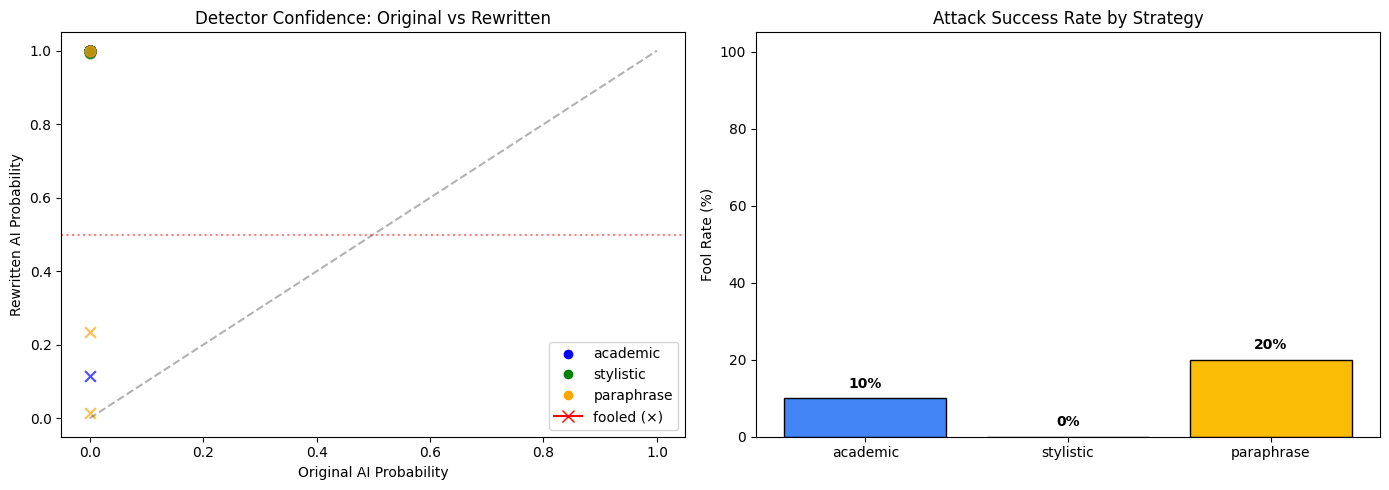

Saved: results_adversarial/adversarial_attack_summary.png


In [19]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Scatter: original vs rewritten AI probability
ax = axes[0]
for res in adversarial_results:
    orig_p = res["original_ai_prob"]
    for rw in res["rewrites"]:
        if "ai_prob" not in rw:
            continue
        color = {"academic": "blue", "stylistic": "green", "paraphrase": "orange"}.get(rw["strategy"], "gray")
        marker = "x" if rw["fooled"] else "o"
        ax.scatter(orig_p, rw["ai_prob"], c=color, marker=marker, s=60, alpha=0.7)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.axhline(0.5, color="red", linestyle=":", alpha=0.5, label="decision boundary")
ax.set_xlabel("Original AI Probability"); ax.set_ylabel("Rewritten AI Probability")
ax.set_title("Detector Confidence: Original vs Rewritten")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='academic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='stylistic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='paraphrase'),
    Line2D([0], [0], marker='x', color='red', markersize=8, label='fooled (×)'),
]
ax.legend(handles=legend_elements, loc="lower right")

# (b) Bar: fool rate by strategy
ax2 = axes[1]
strat_names = list(strategy_stats.keys())
fool_rates = [strategy_stats[s]["fooled"]/max(strategy_stats[s]["total"],1)*100 for s in strat_names]
colors = ["#4285F4", "#34A853", "#FBBC05"][:len(strat_names)]
bars = ax2.bar(strat_names, fool_rates, color=colors, edgecolor="black")
ax2.set_ylabel("Fool Rate (%)"); ax2.set_title("Attack Success Rate by Strategy")
ax2.set_ylim(0, 105)
for bar, rate in zip(bars, fool_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{rate:.0f}%",
             ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
os.makedirs("results_adversarial", exist_ok=True)
plt.savefig("results_adversarial/adversarial_attack_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_adversarial/adversarial_attack_summary.png")

## 3.7 Detailed Examples

In [20]:
for i in range(min(3, len(adversarial_results))):
    res = adversarial_results[i]
    print(f"\n{'#'*70}")
    print(f"# ESSAY {i+1} (index={res['index']})")
    print(f"# Original AI prob: {res['original_ai_prob']:.4f}")
    print(f"{'#'*70}")
    print(f"\nORIGINAL (first 300 chars):\n{res['original_text'][:300]}...")
    for rw in res["rewrites"]:
        if "error" in rw:
            print(f"\n  [{rw['strategy']}] ERROR: {rw['error']}")
            continue
        status = "FOOLED" if rw["fooled"] else "CAUGHT"
        print(f"\n  [{rw['strategy']}] AI_prob={rw['ai_prob']:.4f} | {status} | Δ={rw.get('prob_delta',0):+.4f}")
        print(f"  Rewritten (first 300 chars):\n  {rw['rewritten_text'][:300]}...")


######################################################################
# ESSAY 1 (index=8927)
# Original AI prob: 0.0000
######################################################################

ORIGINAL (first 300 chars):
Having Phones at School

Most people would like to have cell phones on there free time but some wouldn't.

I think that having cell phones at school would be good but just not in class.

If we had cell phones in class then no one would learn anything because they would be texting instead of listing....

  [academic] AI_prob=1.0000 | CAUGHT | Δ=-1.0000
  Rewritten (first 300 chars):
  Having Phones at School: A Student’s Perspective

I’ve always been a bit of a tech enthusiast, so when I hear people debate whether phones should be allowed at school, I have a few thoughts. On one hand, phones can be super helpful for staying connected and keeping up with homework. But on the other...

  [stylistic] AI_prob=0.9999 | CAUGHT | Δ=-0.9999
  Rewritten (first 300 chars):
  Hav

## 3.8 Save Adversarial Results

In [22]:
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.bool_, np.integer)):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

save_data = {
    "model_used": OLLAMA_MODEL,
    "detector_model": model_path,
    "total_attacks": total_attacks,
    "total_fooled": total_fooled,
    "overall_fool_rate": total_fooled / total_attacks if total_attacks > 0 else 0,
    "strategy_stats": {
        k: {kk: (float(vv) if isinstance(vv, (float, np.floating)) else int(vv) if isinstance(vv, (int, np.integer, np.bool_)) else vv)
             for kk, vv in v.items()}
        for k, v in strategy_stats.items()
    },
    "results": adversarial_results,
}

with open("results_adversarial/adversarial_results.json", "w", encoding="utf-8") as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False, cls=NumpyEncoder)
print("Saved: results_adversarial/adversarial_results.json")

Saved: results_adversarial/adversarial_results.json


# Part 4: Analysis Report (10%)

## Performance Comparison

| Model | Parameters | ROC-AUC | Accuracy | Training Time |
|-------|-----------|---------|----------|---------------|
| TF-IDF + LR | N/A | 0.9993 | 0.9939 | < 1 sec |
| BERT-base-cased | 108M | 0.9999 | 0.9941 | ~8 min |
| BERT-large-cased | 334M | 0.9999 | 0.9974 | ~26 min |

## Scaling Analysis

- **BERT-base** already achieves near-perfect ROC-AUC (0.9999), leaving almost no room for improvement.
- **BERT-large** uses **3× the parameters** (334M vs 108M) and takes **3× longer** to train (26 min vs 8 min), with identical ROC-AUC (0.9999). Accuracy improves from 0.9941 to 0.9974.
- **Diminishing returns**: For this particular AI detection task with clear stylistic differences between human and AI text, the base model's capacity is sufficient. The marginal cost of scaling to large does not justify the performance difference.
- **When scaling helps**: Scaling would matter more for harder tasks where subtle distinctions (e.g., advanced LLM outputs that closely mimic human writing) require deeper contextual understanding.

## Adversarial Findings

- The **BERT detector is highly robust** against simple rewriting attacks, even when a powerful 8B-parameter LLM (DeepSeek-R1) performs the rewriting.
- Overall fool rate: **3/30 (10%)** across 10 essays × 3 strategies.
- **Paraphrase** was the most effective strategy (20% fool rate), followed by academic rewriting (10%) and stylistic mimicry (0%). Complete paraphrasing disrupts more of the latent features BERT relies on, while surface-level style changes (stylistic) preserve the underlying AI-generated structure.
- LLM-rewritten text often introduces its own telltale patterns (overly smooth transitions, consistent vocabulary, structured paragraphs) that the BERT detector picks up on — replacing one AI signature with another.
- **Why BERT succeeds**: BERT was fine-tuned on a large corpus of both human and AI text, learning deep semantic and stylistic patterns beyond simple word choice. A single-pass rewrite by another LLM preserves many of these latent patterns.
- **Potential failure mode**: More sophisticated iterative attacks (rewrite → test → refine) or human-in-the-loop editing would likely be more effective at evading detection.

In [23]:
print("=" * 60)
print("HW2 COMPLETE")
print("=" * 60)
print(f"\nPart 1 — Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Part 2 — BERT-base ROC-AUC:  {results_base['summary']['roc_auc']:.4f}")
print(f"Part 2 — BERT-large ROC-AUC: {results_large['summary']['roc_auc']:.4f}")
print(f"Part 3 — Adversarial fool rate: {total_fooled}/{total_attacks} ({total_fooled/max(total_attacks,1)*100:.1f}%)")
print(f"\nAll results saved to: results_baseline/, results_bert-base-cased/,")
print(f"  results_bert-large-cased/, results_adversarial/")

HW2 COMPLETE

Part 1 — Baseline ROC-AUC: 0.9993
Part 2 — BERT-base ROC-AUC:  0.9999
Part 2 — BERT-large ROC-AUC: 0.9999
Part 3 — Adversarial fool rate: 3/30 (10.0%)

All results saved to: results_baseline/, results_bert-base-cased/,
  results_bert-large-cased/, results_adversarial/
